<a href="https://colab.research.google.com/github/Stephen-2-byte/crop-yield-prediction-ml/blob/main/LR_Modelling_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT **PACKAGES**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

# 1. Load your dataset
df = pd.read_csv('/content/RFMODEL.csv')

# 2. Define features and target
features = ['Year', 'NDVI_Flushing', 'NDVI_Flowering', 'NDVI_Fruit Development',
            'EVI_Flushing', 'EVI_Flowering', 'EVI_Fruit Development',
            'GNDVI_Flowering', 'GNDVI_Fruit Development']
target = 'Yield'


# 3. Split dataset
train_df = df[df['Year'] <= 2024]
test_df = df[df['Year'] == 2025]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# 4. Model
lr_model = LinearRegression()

# =========================
# 🔁 K-FOLD CROSS VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#RMSE per fold
cv_rmse = -cross_val_score(
    lr_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=kf
)

# R² per fold
cv_r2 = cross_val_score(
    lr_model,
    X_train,
    y_train,
    scoring='r2',
    cv=kf
)

# MAE per fold
cv_mae = -cross_val_score(
    lr_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=kf
)

print("\n--- Cross-Validation Results (Training Data) ---")

for i, (rmse, mae, r2) in enumerate(zip(cv_rmse, cv_mae, cv_r2), 1):
    print(f"Fold {i}: RMSE = {rmse:.4f}, MAE = {mae:.4f}, R² = {r2:.4f}")

print("\n--- Mean Scores ---")
print(f"Mean RMSE: {cv_rmse.mean():.4f}")
print(f"Mean MAE: {cv_mae.mean():.4f}")
print(f"Mean R²: {cv_r2.mean():.4f}")

# 5. Train final model
lr_model.fit(X_train, y_train)

# 6. Predict 2025
lr_predictions = lr_model.predict(X_test)

# 7. Comparison table
comparison = test_df[['Block', 'Year', 'Yield']].copy()
comparison['LR_Predicted_Yield'] = lr_predictions
comparison['Error'] = comparison['LR_Predicted_Yield'] - comparison['Yield']

print("\n--- 2025 Linear Regression Results ---")
print(comparison.to_string(index=False))

# 8. Final evaluation
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
mae = mean_absolute_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print(f"\nOverall 2025 RMSE: {rmse:.4f}")
print(f"Overall 2025 MAE: {mae:.4f}")
print(f"Overall 2025 R²: {r2:.4f}")


--- Cross-Validation Results (Training Data) ---
Fold 1: RMSE = 3.7691, MAE = 3.2438, R² = 0.6639
Fold 2: RMSE = 4.1603, MAE = 3.5013, R² = 0.8214
Fold 3: RMSE = 5.8901, MAE = 4.3228, R² = 0.5618
Fold 4: RMSE = 6.9355, MAE = 4.8946, R² = 0.5326
Fold 5: RMSE = 7.9534, MAE = 5.0453, R² = 0.2199

--- Mean Scores ---
Mean RMSE: 5.7417
Mean MAE: 4.2016
Mean R²: 0.5599

--- 2025 Linear Regression Results ---
Block  Year     Yield  LR_Predicted_Yield     Error
    A  2025 37.675000           43.066530  5.391530
   A1  2025 34.144000           42.285343  8.141343
   A2  2025 36.000333           39.547523  3.547189
    B  2025 45.616667           41.203348 -4.413319
   B1  2025 36.392000           40.271528  3.879528
   B2  2025 42.321000           38.764133 -3.556867
   B3  2025 40.949667           37.698443 -3.251224
   B4  2025 41.748000           37.926760 -3.821240
   B5  2025 42.440000           41.127703 -1.312297
   C1  2025 37.942333           38.025845  0.083511
   C2  2025 39.922000

In [ ]:

# =========================
# VISUAL CROSS-VALIDATION (APPENDED ONLY)
# =========================

kf_plot = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf_plot.split(X_train), 1):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lr_model.fit(X_tr, y_tr)
    y_pred = lr_model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)

    fold_results.append((y_val, y_pred, rmse, mae))

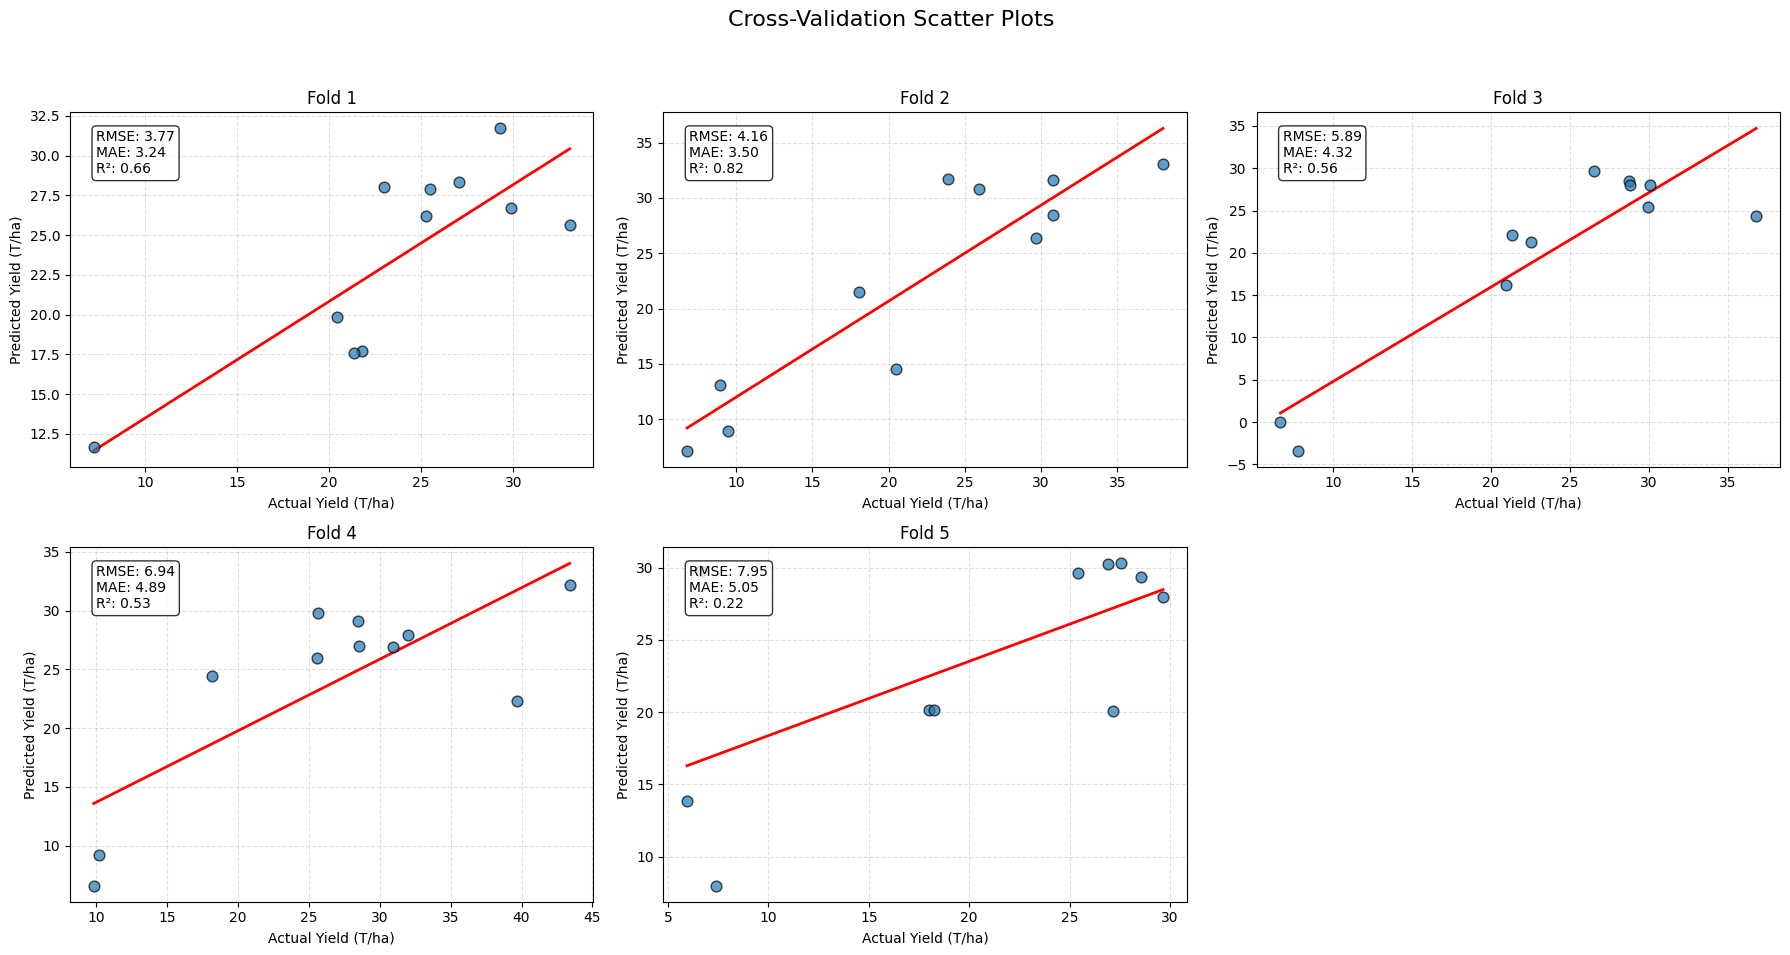

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (y_true, y_pred, rmse, mae) in enumerate(fold_results):
    ax = axes[i]

    # Scatter plot of actual vs predicted
    ax.scatter(y_true, y_pred,
               color='tab:blue',
               edgecolor='black',
               alpha=0.7,
               s=60,
               zorder=3)

    # ==========================================
    # AUTOMATIC LINE OF BEST FIT (Linear Regression)
    # ==========================================
    # Calculate slope (m) and intercept (b) automatically for this specific fold
    z = np.polyfit(y_true, y_pred, 1)
    p = np.poly1d(z)

    # Generate x-values for the line based on the true data range
    x_range = np.linspace(min(y_true), max(y_true), 100)

    # Plot the automatic best-fit line (Green)
    ax.plot(x_range, p(x_range),
            color='red',
            linewidth=2,
            label='Best Fit',
            zorder=2)

    # ==========================================
    # CALCULATE R²
    # ==========================================
    r2 = r2_score(y_true, y_pred)

    # Formatting and labels
    ax.set_title(f"Fold {i+1}", fontsize=12)
    ax.set_xlabel("Actual Yield (T/ha)")
    ax.set_ylabel("Predicted Yield (T/ha)")
    ax.grid(True, linestyle='--', alpha=0.4)

    # Metrics box including R²
    textstr = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.2f}"
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Remove the empty subplot (6th slot)
fig.delaxes(axes[5])

plt.suptitle("Cross-Validation Scatter Plots ", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()

In [ ]:

# TRAIN FINAL MODEL (2020–2024 FULL DATA)
# =========================
lr_model.fit(X_train, y_train)

# =========================
# PREDICT 2025
# =========================
lr_predictions = lr_model.predict(X_test)

# =========================
# CREATE COMPARISON TABLE
# =========================
comparison = test_df[['Block', 'Year', 'Yield']].copy()
comparison['LR_Predicted_Yield'] = lr_predictions
comparison['Error'] = comparison['LR_Predicted_Yield'] - comparison['Yield']

# =========================
# DISPLAY RESULTS
# =========================
print("\n--- 2025 Linear Regression Results ---")
print(comparison.to_string(index=False))

# =========================
# METRICS FOR 2025
# =========================
rmse_2025 = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2_2025 = r2_score(y_test, lr_predictions)
mae_2025 = mean_absolute_error(y_test, lr_predictions)

print("\n--- 2025 Model Performance ---")
print(f"RMSE: {rmse_2025:.4f}")
print(f"MAE: {mae_2025:.4f}")
print(f"R²: {r2_2025:.4f}")


--- 2025 Linear Regression Results ---
Block  Year     Yield  LR_Predicted_Yield     Error
    A  2025 37.675000           43.066530  5.391530
   A1  2025 34.144000           42.285343  8.141343
   A2  2025 36.000333           39.547523  3.547189
    B  2025 45.616667           41.203348 -4.413319
   B1  2025 36.392000           40.271528  3.879528
   B2  2025 42.321000           38.764133 -3.556867
   B3  2025 40.949667           37.698443 -3.251224
   B4  2025 41.748000           37.926760 -3.821240
   B5  2025 42.440000           41.127703 -1.312297
   C1  2025 37.942333           38.025845  0.083511
   C2  2025 39.922000           39.700120 -0.221880

--- 2025 Model Performance ---
RMSE: 4.0683
MAE: 3.4200
R²: -0.5474


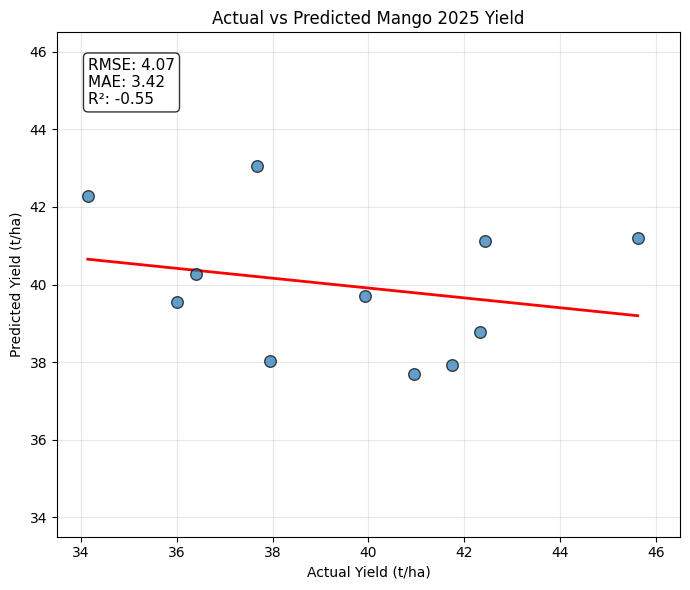

In [ ]:
# =========================
# PLOT
# =========================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from sklearn.metrics import r2_score

plt.figure(figsize=(7, 6))

# Main scatter plot
plt.scatter(y_test, lr_predictions,
            color='tab:blue',
            edgecolor='black',
            alpha=0.7,
            s=70,
            zorder=3)

# =========================
# AUTOMATIC BEST FIT LINE
# =========================
# np.polyfit automatically calculates the slope (m) and intercept (b)
# for the line: y = mx + b
z = np.polyfit(y_test, lr_predictions, 1)
p = np.poly1d(z)

# Generate points for the line based on the actual range of your data
x_range = np.linspace(min(y_test), max(y_test), 100)

plt.plot(x_range, p(x_range),
         color='red',
         linewidth=2,
         label='Best Fit Line',
         zorder=2)

# =========================
# LABELS & RANGE (Matches your image)
# =========================
plt.xlabel("Actual Yield (t/ha)")
plt.ylabel("Predicted Yield (t/ha)")
plt.title("Actual vs Predicted Mango 2025 Yield")

# Setting the window range to match your specific image request
plt.xlim(33.5, 46.5)
plt.ylim(33.5, 46.5)

plt.grid(True, linestyle='-', alpha=0.3)

# =========================
# AXIS FORMATTING
# =========================
ax = plt.gca()
ax.xaxis.set_major_locator(mtick.MultipleLocator(2))
ax.yaxis.set_major_locator(mtick.MultipleLocator(2))
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))

# =========================
# METRICS BOX
# =========================
r2_2025 = r2_score(y_test, lr_predictions)

textstr = (
    f"RMSE: {rmse_2025:.2f}\n"
    f"MAE: {mae_2025:.2f}\n"
    f"R²: {r2_2025:.2f}"
)

plt.text(0.05, 0.95, textstr,
         transform=ax.transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()

plt.show()

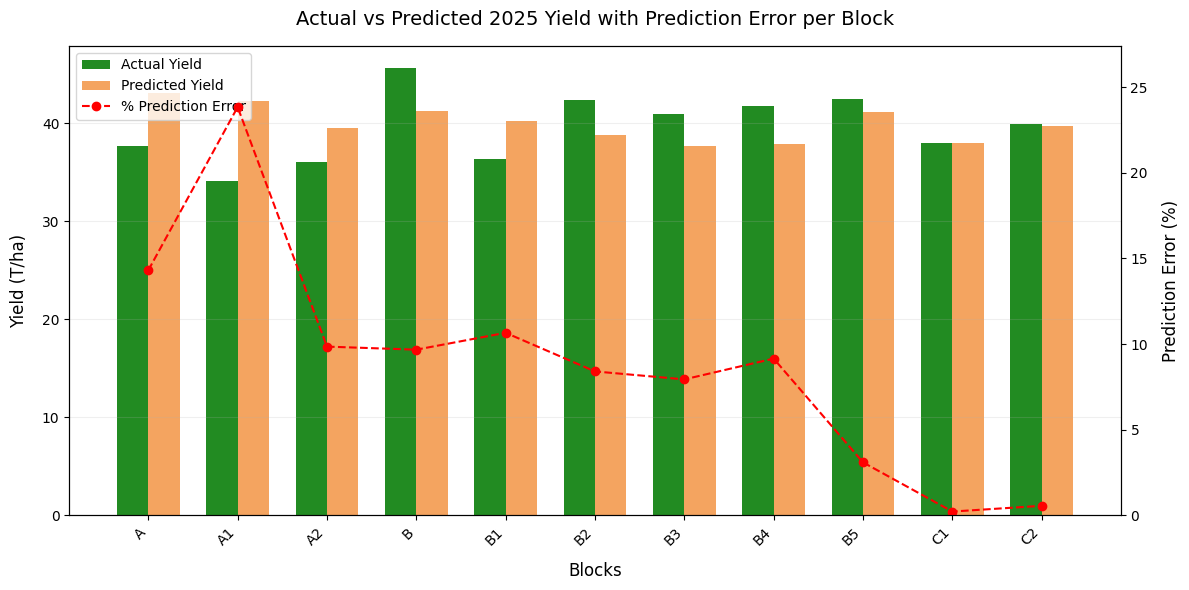

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# DATA
# =========================
blocks = comparison['Block']
actual = comparison['Yield']
predicted = comparison['LR_Predicted_Yield']

# Calculate Percentage Prediction Error dynamically
prediction_error = (np.abs(actual - predicted) / actual) * 100

x = np.arange(len(blocks))
width = 0.35  # Slightly reduced width to prevent bar crowding

# PLOT SETUP (Using subplots for dual-axis handling)
# =========================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Y-Axis: Actual vs Predicted Yield Bars
bar1 = ax1.bar(x - width/2, actual, width,
               label='Actual Yield',
               color='forestgreen')  # Muted green matching your reference

bar2 = ax1.bar(x + width/2, predicted, width,
               label='Predicted Yield',
               color='sandybrown')   # Muted peach/orange matching your reference

ax1.set_xlabel("Blocks", fontsize=12, labelpad=10)
ax1.set_ylabel("Yield (T/ha)", fontsize=12, labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(blocks, rotation=45, ha='right')
ax1.grid(True, linestyle='-', alpha=0.2, axis='y')

# Secondary Y-Axis: Percentage Prediction Error Line
ax2 = ax1.twinx()
line = ax2.plot(x, prediction_error,
                color='red',
                linestyle='--',
                marker='o',
                linewidth=1.5,
                markersize=6,
                label='% Prediction Error')

ax2.set_ylabel("Prediction Error (%)", fontsize=12, color='black', labelpad=10)
ax2.tick_params(axis='y', labelcolor='black')

# Dynamically adjust secondary axis limits to give some headroom
ax2.set_ylim(0, max(prediction_error) * 1.15)

# Title
plt.title("Actual vs Predicted 2025 Yield with Prediction Error per Block", fontsize=14, pad=15)

# Combine legends from both axes into a single box
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', frameon=True, shadow=False)

# Save the plot
plt.tight_layout()


plt.show()

Prediction Error (%) per Block:
A: 14.31%
A1: 23.84%
A2: 9.85%
B: 9.67%
B1: 10.66%
B2: 8.40%
B3: 7.94%
B4: 9.15%
B5: 3.09%
C1: 0.22%
C2: 0.56%

Overall Prediction Error Statistics:
Mean Prediction Error: 8.88%
Minimum Prediction Error: 0.22%
Maximum Prediction Error: 23.84%


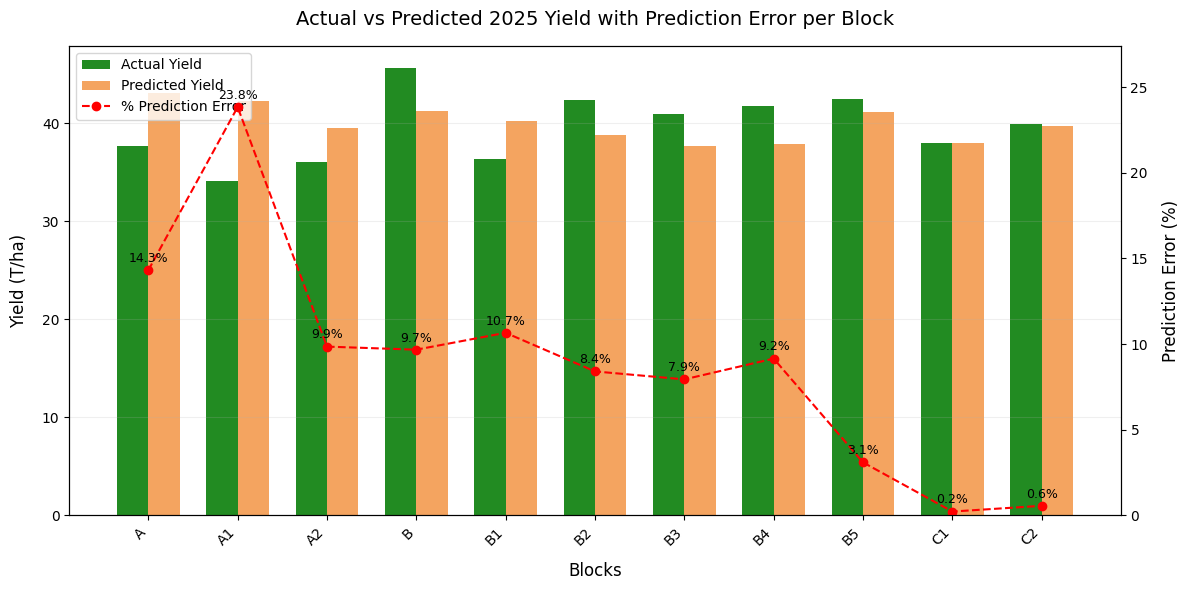

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================
blocks = comparison['Block']
actual = comparison['Yield']
predicted = comparison['LR_Predicted_Yield']

# Calculate Percentage Prediction Error dynamically
prediction_error = (np.abs(actual - predicted) / actual) * 100

# =========================
# PRINT PREDICTION ERROR
# =========================
print("Prediction Error (%) per Block:")
for block, error in zip(blocks, prediction_error):
    print(f"{block}: {error:.2f}%")

# Optional summary statistics
print("\nOverall Prediction Error Statistics:")
print(f"Mean Prediction Error: {prediction_error.mean():.2f}%")
print(f"Minimum Prediction Error: {prediction_error.min():.2f}%")
print(f"Maximum Prediction Error: {prediction_error.max():.2f}%")

# =========================
# PLOT
# =========================
x = np.arange(len(blocks))
width = 0.35  # Slightly reduced width to prevent bar crowding

# PLOT SETUP
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Y-Axis: Actual vs Predicted Yield Bars
bar1 = ax1.bar(x - width/2, actual, width,
               label='Actual Yield',
               color='forestgreen')

bar2 = ax1.bar(x + width/2, predicted, width,
               label='Predicted Yield',
               color='sandybrown')

ax1.set_xlabel("Blocks", fontsize=12, labelpad=10)
ax1.set_ylabel("Yield (T/ha)", fontsize=12, labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(blocks, rotation=45, ha='right')
ax1.grid(True, linestyle='-', alpha=0.2, axis='y')

# Secondary Y-Axis: Percentage Prediction Error Line
ax2 = ax1.twinx()
line = ax2.plot(x, prediction_error,
                color='red',
                linestyle='--',
                marker='o',
                linewidth=1.5,
                markersize=6,
                label='% Prediction Error')

ax2.set_ylabel("Prediction Error (%)", fontsize=12, color='black', labelpad=10)
ax2.tick_params(axis='y', labelcolor='black')

# Dynamically adjust secondary axis limits
ax2.set_ylim(0, max(prediction_error) * 1.15)

# Add value labels for prediction error points
for i, error in enumerate(prediction_error):
    ax2.text(x[i], error + (max(prediction_error) * 0.02),
             f"{error:.1f}%",
             ha='center',
             fontsize=9)

# Title
plt.title("Actual vs Predicted 2025 Yield with Prediction Error per Block",
          fontsize=14, pad=15)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2,
           labels1 + labels2,
           loc='upper left',
           frameon=True)

# Final layout
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# CREATE FINAL TABLE
# =========================
results_2025 = test_df[['Block', 'Year', 'Yield']].copy()

results_2025['Predicted_Yield'] = lr_predictions
results_2025['Error'] = results_2025['Predicted_Yield'] - results_2025['Yield']

# =========================
# SAVE TO CSV
# =========================
results_2025.to_csv("2025_yield_predictions.csv", index=False)

print("CSV file saved successfully: 2025_yield_predictions.csv")

CSV file saved successfully: 2025_yield_predictions.csv


In [ ]:
import geopandas as gpd

# =========================
# CHECK COLUMN NAMES FIRST
# =========================
# Define gdf here to resolve NameError if this cell is run independently
gdf = gpd.read_file('Projected_MangoBlocks.shp')

print("Shapefile columns:")
print(gdf.columns)

print("\nComparison table columns:")
print(comparison.columns)

Shapefile columns:
Index(['Block_Name', 'geometry'], dtype='object')

Comparison table columns:
Index(['Block', 'Year', 'Yield', 'LR_Predicted_Yield', 'Error'], dtype='object')


In [ ]:
!pip install contextily

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

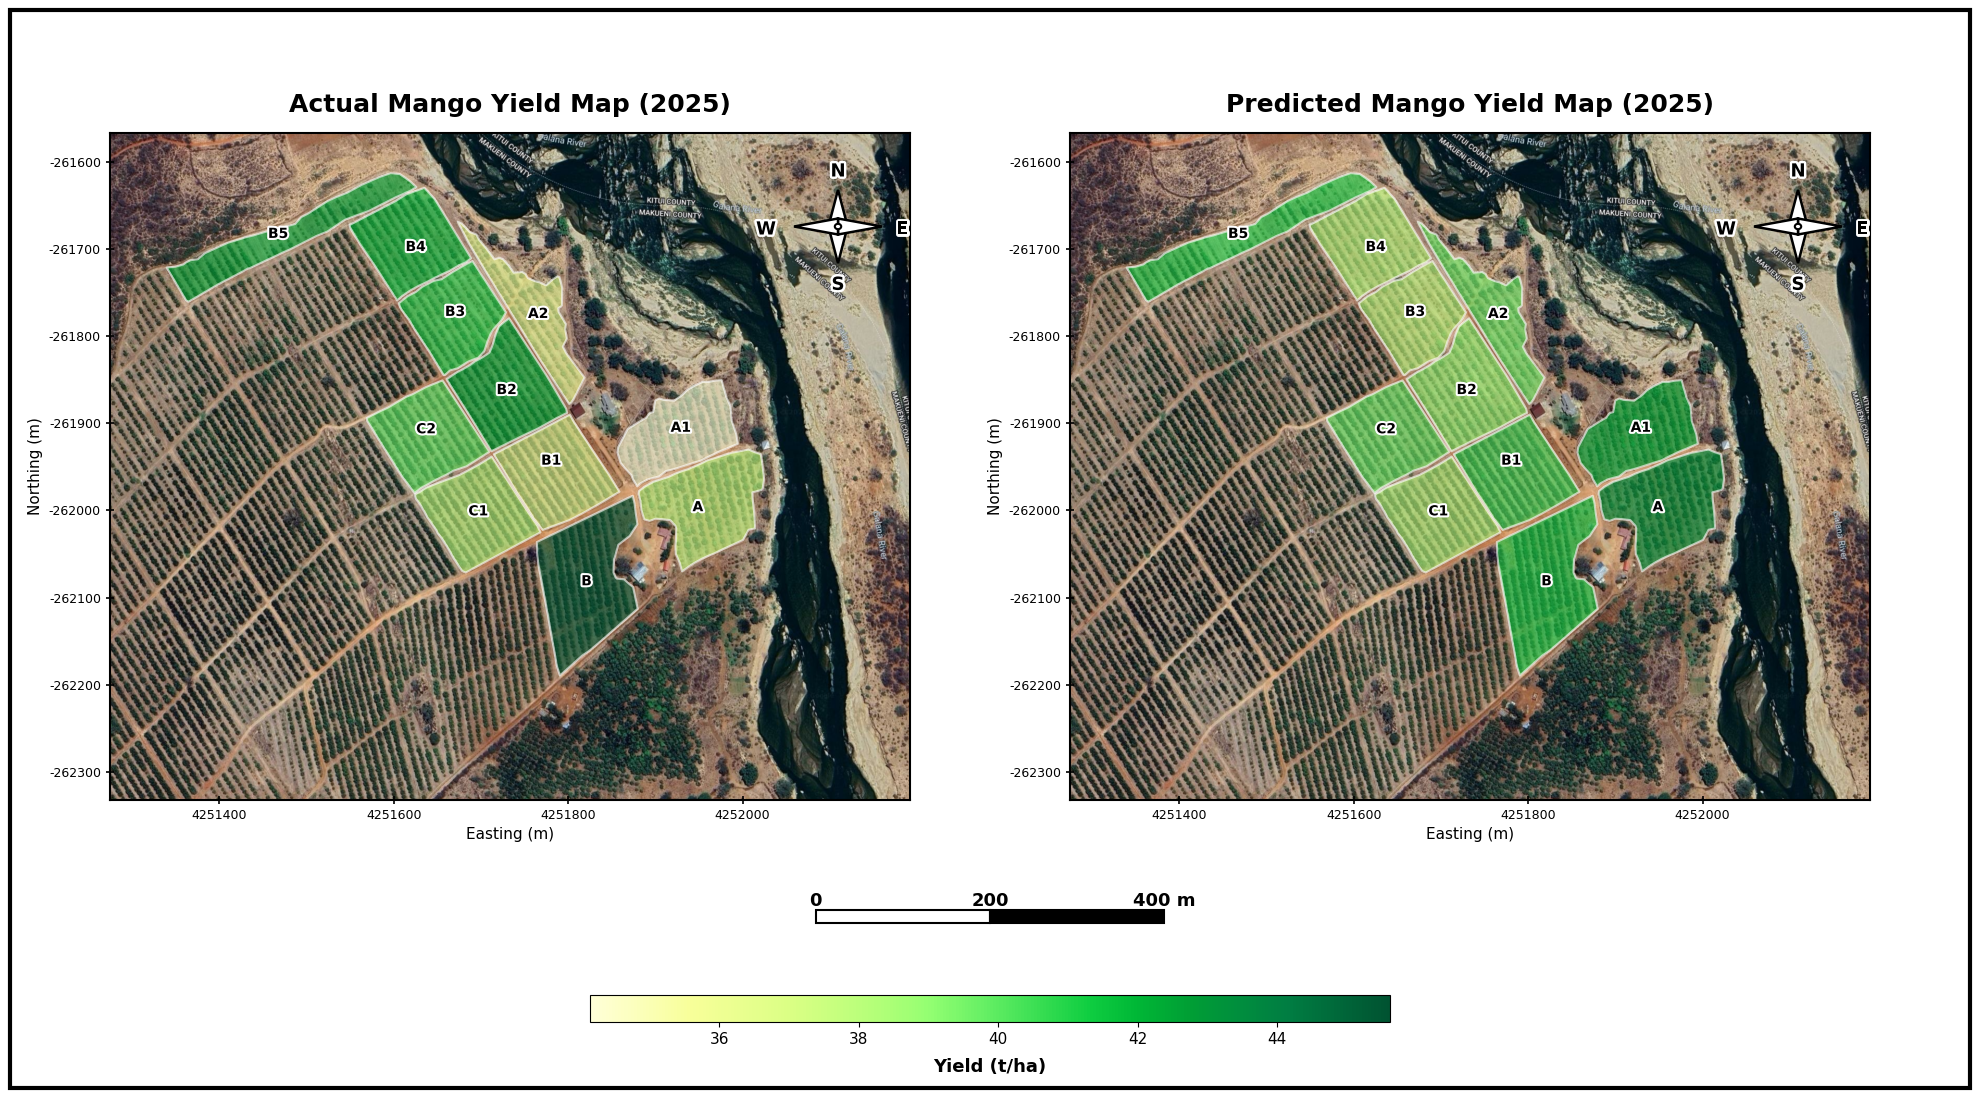

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import ListedColormap, rgb_to_hsv, hsv_to_rgb
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Polygon, Rectangle, Circle
from matplotlib import patheffects
import contextily as ctx

# 1. Custom Saturated YlGn Colormap
original_cmap = plt.get_cmap("YlGn")
colors = original_cmap(np.linspace(0, 1, 256))[:, :3]
hsv_colors = rgb_to_hsv(colors)
hsv_colors[:, 1] = np.clip(hsv_colors[:, 1] * 1.5, 0, 1)  # saturation
hsv_colors[:, 2] = np.clip(hsv_colors[:, 2] * 1.2, 0, 1)  # brightness
custom_ylgn = ListedColormap(hsv_to_rgb(hsv_colors))

# 2. Data Loading & Preparation
gdf = gpd.read_file('Projected_MangoBlocks.shp')

# Merging comparison dataframe (Actual vs Predicted)
gdf = gdf.merge(
    comparison[['Block', 'Yield', 'LR_Predicted_Yield']],
    left_on='Block_Name',
    right_on='Block',
    how='left'
)
# Projection
gdf = gdf.to_crs(epsg=3857)

# min/max across both Actual and Predicted
vmin = min(gdf['Yield'].min(), gdf['LR_Predicted_Yield'].min())
vmax = max(gdf['Yield'].max(), gdf['LR_Predicted_Yield'].max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Google Satellite URL
google_satellite = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"

# ------------------------------
# 3. Uniform High-Intensity GIS Compass
# ------------------------------
def draw_detailed_compass(ax):
    """
    Draws a perfectly symmetrical, high-contrast 4-point star compass.
    Uses uniform vector calculations to prevent distortion from subplot aspect ratios.
    """
    # Anchor center position in the top right corner
    x0, y0 = 0.91, 0.86

    # Scale dimensions for high visibility
    r_long = 0.055  # Length of main pointers
    r_short = 0.012 # Width/flank of the arrow base

    # Symmetrical point coordinates: [Tip point, Left flank corner, Right flank corner]
    points = [
        # NORTH (Points straight up)
        ([[x0, y0 + r_long], [x0 - r_short, y0], [x0 + r_short, y0]], 'N', x0, y0 + r_long + 0.02),
        # SOUTH (Points straight down)
        ([[x0, y0 - r_long], [x0 + r_short, y0], [x0 - r_short, y0]], 'S', x0, y0 - r_long - 0.04),
        # EAST (Points straight right)
        ([[x0 + r_long, y0], [x0, y0 + r_short], [x0, y0 - r_short]], 'E', x0 + r_long + 0.025, y0 - 0.012),
        # WEST (Points straight left)
        ([[x0 - r_long, y0], [x0, y0 - r_short], [x0, y0 + r_short]], 'W', x0 - r_long - 0.035, y0 - 0.012)
    ]

    # Draw fully white pointer spikes with heavy outlines
    for poly_pts, label, tx, ty in points:
        spine = Polygon(poly_pts, facecolor='white', edgecolor='black', linewidth=1.8, transform=ax.transAxes, zorder=5)
        ax.add_patch(spine)

        # Labels with a highly defined white background halo for legibility over dark imagery
        t = ax.text(tx, ty, label, transform=ax.transAxes, ha='center', weight='bold', fontsize=13, color='black', zorder=6)
        t.set_path_effects([patheffects.withStroke(linewidth=3.5, foreground='white')])

    # Center core pin accent
    center_dot = Circle((x0, y0), 0.004, facecolor='white', edgecolor='black', linewidth=1.5, transform=ax.transAxes, zorder=6)
    ax.add_patch(center_dot)

# ------------------------------
# 4. Large Common Scale Bar Function
# ------------------------------
def draw_common_scalebar(fig, target_ax, length_m=400):
    """Draws one large common graphic scale bar at the bottom center of the figure."""
    xmin, xmax = target_ax.get_xlim()
    bbox = target_ax.get_window_extent().transformed(fig.transFigure.inverted())
    fig_width_meters = xmax - xmin

    scale_width_fig = (length_m / fig_width_meters) * bbox.width

    # Dynamic central positioning above colorbar
    x_start = 0.5 - (scale_width_fig / 2)
    y_start = 0.16
    height = 0.012

    rec1 = Rectangle((x_start, y_start), scale_width_fig/2, height,
                     facecolor='white', edgecolor='black', linewidth=1.5, transform=fig.transFigure, zorder=10)
    rec2 = Rectangle((x_start + scale_width_fig/2, y_start), scale_width_fig/2, height,
                     facecolor='black', edgecolor='black', linewidth=1.5, transform=fig.transFigure, zorder=10)

    fig.artists.append(rec1)
    fig.artists.append(rec2)

    label_props = dict(fontsize=13, weight='bold', color='black', ha='center', transform=fig.transFigure, zorder=11)
    fig.text(x_start, y_start + height * 1.3, "0", **label_props)
    fig.text(x_start + scale_width_fig/2, y_start + height * 1.3, f"{int(length_m/2)}", **label_props)
    fig.text(x_start + scale_width_fig, y_start + height * 1.3, f"{length_m} m", **label_props)

# ------------------------------
# 5. Core Figure Setup & Plotting
# ------------------------------
fig, ax = plt.subplots(1, 2, figsize=(20, 11))

plot_cols = ['Yield', 'LR_Predicted_Yield']
titles = ["Actual Mango Yield Map (2025)", "Predicted Mango Yield Map (2025)"]

for i, col in enumerate(plot_cols):
    # Plot blocks with transparency
    gdf.plot(
        column=col, cmap=custom_ylgn, norm=norm,
        edgecolor="white", linewidth=1.5, alpha=0.6, ax=ax[i], zorder=2
    )

    # Add Google Satellite Basemap
    ctx.add_basemap(ax[i], source=google_satellite, zoom=18, reset_extent=False)

    # Titles and Axis formatting
    ax[i].set_title(titles[i], fontsize=18, weight='bold', pad=15)
    ax[i].tick_params(labelsize=9, colors='black', direction='inout', length=6, width=1.2)
    ax[i].xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax[i].set_xlabel("Easting (m)", fontsize=11)
    ax[i].set_ylabel("Northing (m)", fontsize=11)

    # Subplot Neatline Frame
    for spine in ax[i].spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    # Block Labels with White Halo
    for _, row in gdf.iterrows():
        c = row.geometry.representative_point().coords[0]
        lbl = ax[i].text(c[0], c[1], row["Block_Name"], fontsize=10,
                         ha='center', weight='bold', color='black', zorder=4)
        lbl.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])

    # Add custom symmetric detailed compass to each plot
    draw_detailed_compass(ax[i])

# ------------------------------
# 6. Global Frames, Colorbar, and Common Scale Bar
# ------------------------------
fig.subplots_adjust(left=0.06, right=0.94, top=0.91, bottom=0.24, wspace=0.20)

# Shared Horizontal Colorbar positioned cleanly at the bottom
cax = fig.add_axes([0.3, 0.07, 0.4, 0.025])
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=custom_ylgn), cax=cax, orientation='horizontal')
cb.set_label("Yield (t/ha)", fontsize=13, weight='bold', labelpad=8)
cb.ax.tick_params(labelsize=11)

# Add the Unified Outer Layout Frame (Encloses all elements)
global_frame = Rectangle((0.01, 0.01), 0.98, 0.98, fill=False,
                         edgecolor='black', linewidth=3.0, transform=fig.transFigure, zorder=20)
fig.artists.append(global_frame)

# Draw Single Common Graphic Scale Bar
draw_common_scalebar(fig, target_ax=ax[0], length_m=400)

plt.savefig("Actual_vs_Predicted_20251.png", dpi=300)
from google.colab import files
files.download("Actual_vs_Predicted_20251.png")
plt.show()

In [ ]:
# =========================
# LOAD WHOLE FARM 2025 DATA
# =========================
whole_farm_df = pd.read_csv('/content/Cleaned_Vegetation_Indices.csv')

# =========================
# ADD YEAR COLUMN (ALL DATA IS 2025)
# =========================
whole_farm_df['Year'] = 2025

# =========================
# ARRANGE FEATURES IN EXACT MODEL ORDER
# =========================
X_whole_farm = whole_farm_df[['Year',
                              'NDVI_Flushing',
                              'NDVI_Flowering',
                              'NDVI_Fruit Development',
                              'EVI_Flushing',
                              'EVI_Flowering',
                              'EVI_Fruit Development',
                              'GNDVI_Flowering',
                              'GNDVI_Fruit Development']]

# =========================
# PREDICT WHOLE FARM 2025 YIELD
# =========================
whole_farm_predictions = lr_model.predict(X_whole_farm)

# =========================
# CREATE FINAL RESULTS TABLE
# =========================
whole_farm_results = whole_farm_df[['Block']].copy()
whole_farm_results['Year'] = 2025
whole_farm_results['Predicted_Yield'] = whole_farm_predictions

# =========================
# DISPLAY RESULTS
# =========================
print("\n--- WHOLE FARM 2025 YIELD PREDICTIONS ---")
print(whole_farm_results.to_string(index=False))

# =========================
# SAVE RESULTS TO CSV
# =========================
whole_farm_results.to_csv("WHOLE_FARM_2025_Predicted_Yield.csv", index=False)

print("\nCSV file saved successfully: WHOLE_FARM_2025_Predicted_Yield.csv")


--- WHOLE FARM 2025 YIELD PREDICTIONS ---
Block  Year  Predicted_Yield
    A  2025        43.066530
   A1  2025        42.285343
   A2  2025        39.547523
    B  2025        41.203348
   B1  2025        40.271528
   B2  2025        38.764133
   B3  2025        37.698443
   B4  2025        37.926760
   B5  2025        41.127703
   C1  2025        38.025845
   C2  2025        39.700120
   D1  2025        38.690340
   D2  2025        37.066294
   D3  2025        36.128384
   D4  2025        34.782332
   C3  2025        37.628166
   C4  2025        35.442107
   E2  2025        36.865277
   E1  2025        42.365355
   E3  2025        38.653130
   E4  2025        41.187268
   E5  2025        36.020129
    C  2025        34.097346
    E  2025        43.315119
    D  2025        38.519114
    G  2025        33.991971
   G1  2025        35.916523
   G2  2025        39.295241
   G3  2025        41.084589
   G4  2025        35.657133
   G5  2025        40.964844
    F  2025        36.983090


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

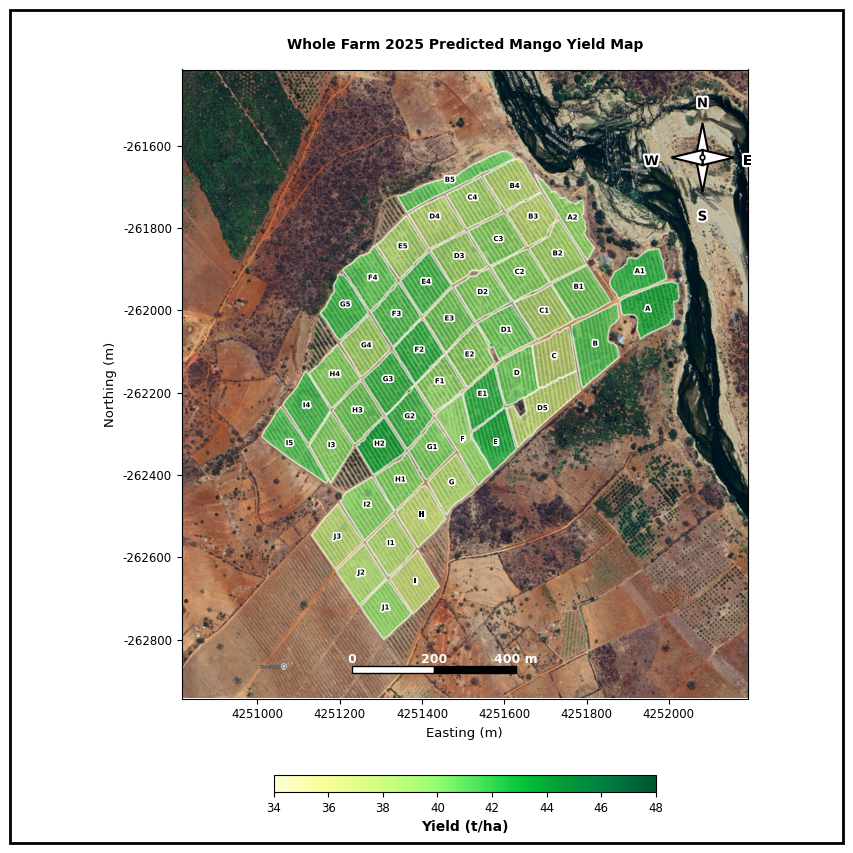

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, rgb_to_hsv, hsv_to_rgb
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Polygon, Rectangle, Circle
from matplotlib import patheffects
import contextily as ctx

# ==========================================
# 1. LOAD & STANDARDIZE DATA
# ==========================================
gdf = gpd.read_file("/content/merged_blocks.shp")
df = pd.read_csv("/content/Cleaned_Vegetation_Indices.csv")

# Reference blocks for normalization
ref_blocks = ['A', 'A1', 'A2', 'B', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2']
df_ref = df[df['Block'].isin(ref_blocks)].copy()
df_noisy = df[~df['Block'].isin(ref_blocks)].copy()

# Standardize to remove soil/background noise
numeric_cols = [col for col in df.columns if col != 'Block']
df_std = df.copy()

for col in numeric_cols:
    ref_m, ref_s = df_ref[col].mean(), df_ref[col].std()
    n_m, n_s = df_noisy[col].mean(), df_noisy[col].std()
    df_std.loc[~df_std['Block'].isin(ref_blocks), col] = \
        ((df_std.loc[~df_std['Block'].isin(ref_blocks), col] - n_m) * (ref_s / (n_s if n_s != 0 else 1))) + ref_m

# ==========================================
# 2. MODEL PREDICTION
# ==========================================
df_std['Year'] = 2025
X = df_std[['Year', 'NDVI_Flushing', 'NDVI_Flowering', 'NDVI_Fruit Development',
            'EVI_Flushing', 'EVI_Flowering', 'EVI_Fruit Development',
            'GNDVI_Flowering', 'GNDVI_Fruit Development']]

# Ensure lr_model is already trained/loaded in your workspace
df_std['Predicted_Yield'] = lr_model.predict(X)

# Merge and Project
gdf = gdf.merge(df_std[['Block', 'Predicted_Yield']], left_on='Block_Name', right_on='Block', how='left')
gdf = gdf.to_crs(epsg=3857)

# ==========================================
# 3. SYNCED SYMBOLOGY (From Reference Code)
# ==========================================
vmin, vmax = 34, 48

original_cmap = plt.get_cmap("YlGn")
colors = original_cmap(np.linspace(0, 1, 256))[:, :3]
hsv_colors = rgb_to_hsv(colors)
hsv_colors[:, 1] = np.clip(hsv_colors[:, 1] * 1.5, 0, 1)  # Saturation boost
hsv_colors[:, 2] = np.clip(hsv_colors[:, 2] * 1.2, 0, 1)  # Brightness boost
custom_ylgn = ListedColormap(hsv_to_rgb(hsv_colors))

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ==========================================
# 4. CUSTOM CARTOGRAPHIC HELPERS
# ==========================================
def draw_detailed_compass(ax):
    """Draws a crisp white compass rose inside the map panel."""
    x0, y0 = 0.92, 0.86
    r_long = 0.055
    r_short = 0.012

    points = [
        ([[x0, y0 + r_long], [x0 - r_short, y0], [x0 + r_short, y0]], 'N', x0, y0 + r_long + 0.025),
        ([[x0, y0 - r_long], [x0 + r_short, y0], [x0 - r_short, y0]], 'S', x0, y0 - r_long - 0.045),
        ([[x0 + r_long, y0], [x0, y0 + r_short], [x0, y0 - r_short]], 'E', x0 + r_long + 0.025, y0 - 0.012),
        ([[x0 - r_long, y0], [x0, y0 - r_short], [x0, y0 + r_short]], 'W', x0 - r_long - 0.035, y0 - 0.012)
    ]

    for poly_pts, label, tx, ty in points:
        spine = Polygon(poly_pts, facecolor='white', edgecolor='black', linewidth=1.5, transform=ax.transAxes, zorder=5)
        ax.add_patch(spine)

        t = ax.text(tx, ty, label, transform=ax.transAxes, ha='center', weight='bold', fontsize=9.5, color='black', zorder=6)
        t.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])

    center_dot = Circle((x0, y0), 0.004, facecolor='white', edgecolor='black', linewidth=1.2, transform=ax.transAxes, zorder=6)
    ax.add_patch(center_dot)

def draw_graphic_scalebar(ax, length_m=400):
    """Draws a compact checkerboard scale bar aligned at the bottom center of the map grid."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_start = xmin + (xmax - xmin) * 0.30
    y_start = ymin + (ymax - ymin) * 0.04
    height = (ymax - ymin) * 0.012

    rec1 = Rectangle((x_start, y_start), length_m/2, height,
                     facecolor='white', edgecolor='black', linewidth=1.0, zorder=10)
    rec2 = Rectangle((x_start + length_m/2, y_start), length_m/2, height,
                     facecolor='black', edgecolor='black', linewidth=1.0, zorder=10)

    ax.add_patch(rec1)
    ax.add_patch(rec2)

    label_props = dict(fontsize=9, weight='bold', color='white', ha='center', zorder=11)
    ax.text(x_start, y_start + height * 1.4, "0", **label_props)
    ax.text(x_start + length_m/2, y_start + height * 1.4, f"{int(length_m/2)}", **label_props)
    ax.text(x_start + length_m, y_start + height * 1.4, f"{length_m} m", **label_props)

# ==========================================
# 5. PLOTTING WITH REDUCED HORIZONTAL GAP
# ==========================================
# Modified to a uniform square (8.5x8.5) shape to pull the sides tightly to the grid frame
fig, ax = plt.subplots(1, 1, figsize=(8.5, 8.5))

google_satellite = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"

# Plot blocks
gdf.plot(
    column='Predicted_Yield', cmap=custom_ylgn, norm=norm,
    edgecolor="white", linewidth=1.2, alpha=0.6, ax=ax, zorder=2
)

# Add Google Satellite Basemap
ctx.add_basemap(ax, source=google_satellite, zoom=18, reset_extent=False)

# Block Labels with White Halo
for _, row in gdf.iterrows():
    if row.geometry is not None:
        c = row.geometry.representative_point().coords[0]
        lbl = ax.text(c[0], c[1], row["Block_Name"], fontsize=5,
                      ha='center', weight='bold', color='black', zorder=4)
        lbl.set_path_effects([patheffects.withStroke(linewidth=2.5, foreground='white')])

# Map Formatting
ax.set_title("Whole Farm 2025 Predicted Mango Yield Map", fontsize=10, weight='bold', pad=15)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_xlabel("Easting (m)", fontsize=9.5)
ax.set_ylabel("Northing (m)", fontsize=9.5)
ax.tick_params(labelsize=8.5)

# Elements added to data frame
draw_detailed_compass(ax)
draw_graphic_scalebar(ax, length_m=400)

# Pull the neatline tight horizontally against the inner plot boundaries
fig.subplots_adjust(left=0.12, right=0.97, bottom=0.18, top=0.92)

# Shared Colorbar Placement
cax = fig.add_axes([0.32, 0.07, 0.45, 0.02])
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=custom_ylgn), cax=cax, orientation='horizontal')
cb.set_label("Yield (t/ha)", fontsize=10, weight='bold', labelpad=4)
cb.ax.tick_params(labelsize=8.5)

# ==========================================
# 6. ADJUSTED BOUNDING BOX FRAME
# ==========================================
# The border anchors are shifted to match the tight subplot adjustments
global_frame = Rectangle((0.01, 0.01), 0.98, 0.98, fill=False,
                         edgecolor='black', linewidth=2.0, transform=fig.transFigure, zorder=20)
fig.artists.append(global_frame)

# Bbox tight forces output rendering engines to drop unallocated white space margins
plt.savefig("Whole_Farm_Predicted_Yield_2025_Final1.png", dpi=300, bbox_inches='tight')
from google.colab import files
files.download("Whole_Farm_Predicted_Yield_2025_Final1.png")
plt.show()